In [1]:
import os
import sys
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.sparse as sp
import scipy.io as sio
import pickle
from scipy import sparse
sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

In [2]:
traj = "myeloid"
data_root = "/home/wuyan/dygmamba_project/NewRealPlan/Case1/process/"
data_path = data_root + traj + "/process/"

adata_rna = ad.read_h5ad(data_path + 'rna_processed.h5ad')
adata_atac = ad.read_h5ad(data_path + 'atac_processed.h5ad')

adata_atac.var_names = adata_atac.var_names.str.replace(':', '-', regex=False)


## processed umap

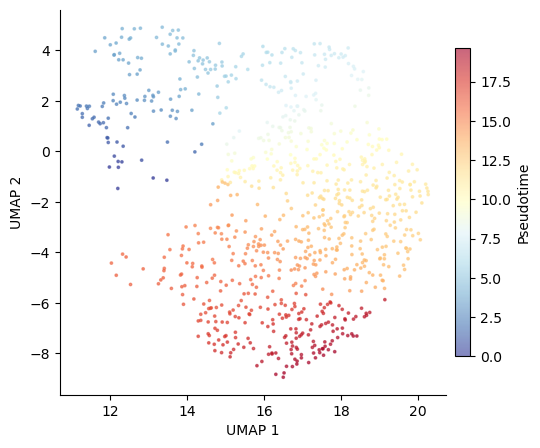

In [3]:
import matplotlib.pyplot as plt

umap_coords = adata_rna.obsm['X_umap'] 
pseudotime = adata_rna.obs['pseudotime'].values

fig, ax = plt.subplots(figsize=(6, 5))

sc = ax.scatter(
    umap_coords[:, 0], umap_coords[:, 1],
    c=pseudotime, cmap='RdYlBu_r',
    s=3, alpha=0.6, rasterized=True
)
fig.colorbar(sc, ax=ax, label='Pseudotime', shrink=0.8, pad=0.02)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.spines[['top','right']].set_visible(False)


## processed pseudotime

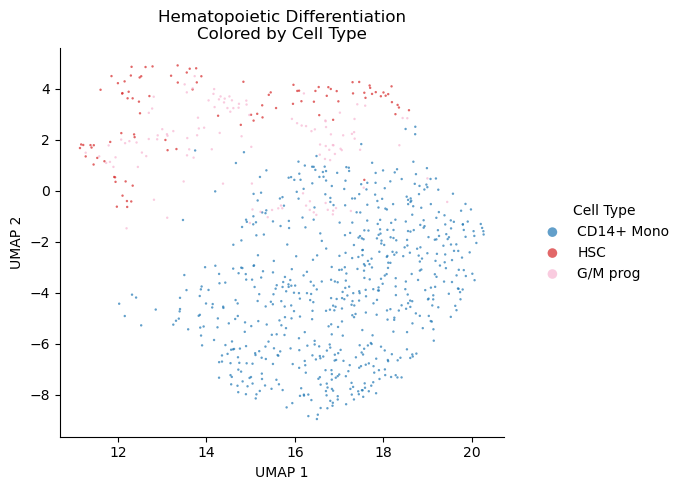

In [4]:
# 1. 提取坐标和细胞类型数据
umap_coords = adata_rna.obsm['X_umap']
cell_types = adata_rna.obs['cell_type']  # 假设列名是 'cell_type'

unique_cell_types = cell_types.unique()

cmap = plt.get_cmap('tab20')
color_dict = {ct: cmap(i / len(unique_cell_types)) for i, ct in enumerate(unique_cell_types)}

fig, ax = plt.subplots(figsize=(7, 5))  

for ct in unique_cell_types:
    mask = (cell_types == ct)
    ax.scatter(
        umap_coords[mask, 0], umap_coords[mask, 1],
        color=color_dict[ct],     # 指定颜色
        label=ct,                 # 指定图例名称
        s=3, alpha=0.7, rasterized=True, edgecolors='none'
    )

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Hematopoietic Differentiation\nColored by Cell Type')
ax.spines[['top', 'right']].set_visible(False)

ax.legend(
    loc='center left', 
    bbox_to_anchor=(1.05, 0.5), # 放在右侧外部
    frameon=False, 
    title='Cell Type',
    markerscale=4 
)

plt.tight_layout()

## Origin umap

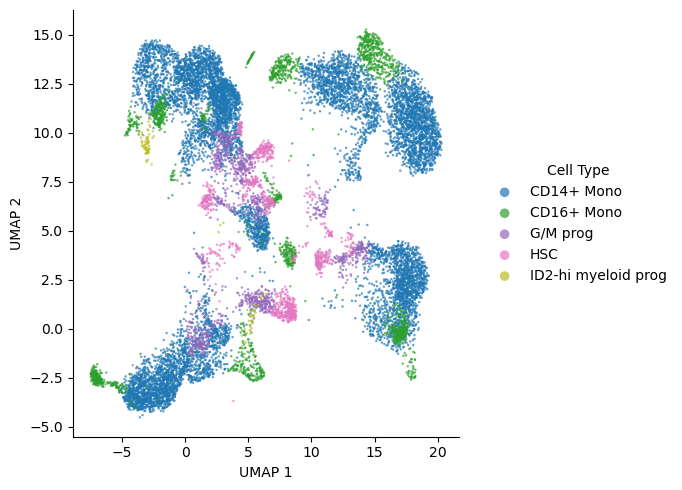

In [5]:
adata_rna_origin = ad.read_h5ad(data_path + 'rna_origin.h5ad')

def self_umap(adata_rna):
    umap_coords = adata_rna.obsm['GEX_X_umap']
    cell_types = adata_rna.obs['cell_type']  # 假设列名是 'cell_type'

    unique_cell_types = cell_types.unique()

    cmap = plt.get_cmap('tab20')
    color_dict = {ct: cmap(i / len(unique_cell_types)) for i, ct in enumerate(unique_cell_types)}

    fig, ax = plt.subplots(figsize=(7, 5))  

    for ct in unique_cell_types:
        mask = (cell_types == ct)
        ax.scatter(
            umap_coords[mask, 0], umap_coords[mask, 1],
            color=color_dict[ct],     # 指定颜色
            label=ct,                 # 指定图例名称
            s=3, alpha=0.7, rasterized=True, edgecolors='none'
        )

    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(
        loc='center left', 
        bbox_to_anchor=(1.05, 0.5), # 放在右侧外部
        frameon=False, 
        title='Cell Type',
        markerscale=4 
    )

    plt.tight_layout()
    
self_umap(adata_rna_origin)

## Pseudotime distribution

/tmp/ipykernel_102062/3689834955.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


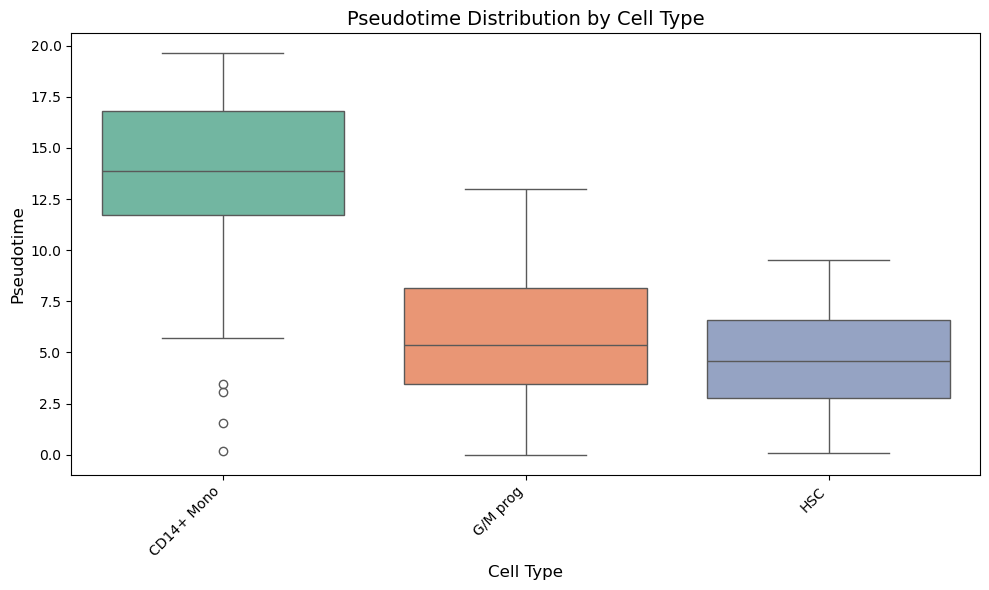

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置画布大小，确保有足够的空间展示所有的类别（可根据类别数量自行调整）
plt.figure(figsize=(10, 6))

# 2. 绘制箱线图
# 直接将 adata_rna.obs 传给 data 参数
sns.boxplot(
    data=adata_rna.obs, 
    x="cell_type",      # X轴：细胞类型
    y="pseudotime",     # Y轴：伪时间
    palette="Set2"      # 使用一个柔和的调色板（可选参数）
)

# 3. 美化图表
plt.title("Pseudotime Distribution by Cell Type", fontsize=14)
plt.xlabel("Cell Type", fontsize=12)
plt.ylabel("Pseudotime", fontsize=12)

# 如果你的细胞类型名称（如 "ID2-hi myeloid prog"）比较长，
# 建议旋转 X 轴标签，防止文字相互重叠看不清
plt.xticks(rotation=45, ha="right")

# 自动调整子图参数，使之填充整个图像区域
plt.tight_layout() 

# 4. 显示（或保存）图像
plt.show()
# 如果你想保存到本地，可以把 plt.show() 替换为：
# plt.savefig("pseudotime_boxplot.pdf", dpi=300)

# Test

## TF-Peak

          TF                       Peak    score   p-value  q-value     value
154094  RORA     chr1-28648132-28649066  17.2921  0.000002   1.0000  5.798603
154095  RFX2    chr17-41665633-41666554  15.7429  0.000002   0.0764  5.798603
154096    Ar     chr6-35727670-35728580  16.4483  0.000002   0.5410  5.798603
154097  Spi1   chr4-141311466-141312275  16.1789  0.000002   0.0543  5.798603
154098  Spi1  chr10-110497413-110498258  16.1789  0.000002   0.0543  5.798603


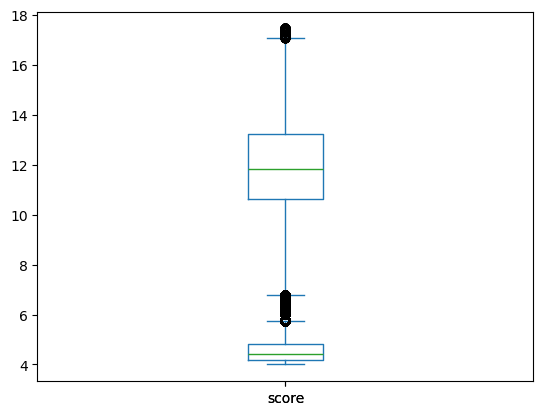

In [7]:
jaspar_data = pd.read_pickle(data_path + "jaspar_df.pkl")
jaspar_data['sequence_name'] = jaspar_data['sequence_name'].str.replace(':','-')
jaspar_tf_peak = jaspar_data[['TF_Symbol', 'sequence_name', 'score', 'p-value', 'q-value']].copy()
jaspar_tf_peak.rename(columns= {'TF_Symbol': 'TF', 'sequence_name':'Peak'}, inplace = True)
jaspar_tf_peak.drop_duplicates(subset=['TF','Peak'], keep= 'first', inplace= True)
jaspar_tf_peak['value'] = - np.log10(jaspar_tf_peak['p-value'])

jaspar_filter_df = jaspar_tf_peak[jaspar_tf_peak["TF"].isin(set(adata_rna.var_names))]
jaspar_filter_df = jaspar_filter_df[jaspar_filter_df["Peak"].isin(set(adata_atac.var_names))]

score_mask = (jaspar_tf_peak['score']> 6 ) & (jaspar_tf_peak['score']< 17.5 )
value_mask= jaspar_tf_peak['value'] < 5.8
combined_mask = score_mask & value_mask

tf_peak_grn = jaspar_tf_peak[combined_mask].copy()

tf_peak_grn['value'].plot.box()
tf_peak_grn['score'].plot.box()

tf_peak_grn.to_pickle(data_path + 'pred_tf_peak.pkl')

print(tf_peak_grn.head())

# jaspar_tf_peak = jaspar_tf_peak[jaspar_tf_peak['q-value']< jaspar_q_threshold ]
# jaspar_tf_peak = jaspar_tf_peak[jaspar_tf_peak['score']> jaspar_score_threshold]
# mask = (jaspar_tf_peak['value']> jaspar_threshold ) & (jaspar_tf_peak['value']< 8)

# new_jaspar_tf_peak = jaspar_tf_peak.loc[mask,['TF', 'Peak', 'value']].copy()

# new_jaspar_tf_peak.to_pickle(data_path + 'process/pred_tf_peak.pkl')

## Peak-Gene

                      Peak      Gene         ts   predict
0  chr19-58097867-58098766  A1BG-AS1   5.507392  0.999015
1  chr19-58097867-58098766  A1BG-AS1   8.113485  0.998914
2  chr19-58097867-58098766  A1BG-AS1  17.961752  0.998765
3  chr19-58097867-58098766  A1BG-AS1   4.367930  0.998847
4  chr19-58097867-58098766  A1BG-AS1  12.494371  0.998305
                       Peak      Gene  avg_ts_weight  avg_total_weight  \
0  chr1-100037698-100038501  RTCA-AS1       0.991734        139.834534   
1      chr1-1000553-1001085  C1orf159       0.970310         61.129536   
2      chr1-1000553-1001085     ISG15       0.972094         61.241913   
3      chr1-1000553-1001085    KLHL17       0.997508         62.843029   
4  chr1-100132564-100133476  RTCA-AS1       0.988186        155.145142   

   predict     value  
0        1  0.991734  
1        1  0.970310  
2        1  0.972094  
3        1  0.997508  
4        1  0.988186  


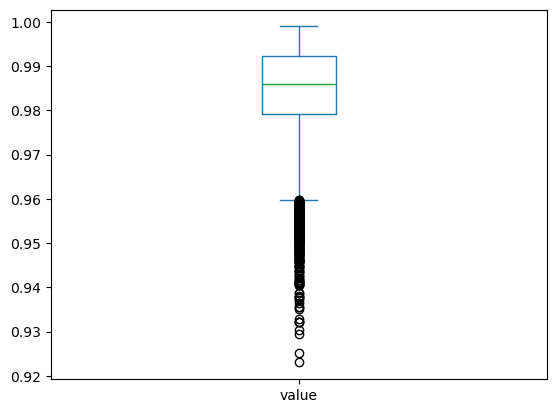

In [8]:
total_peak = set(adata_atac.var_names)

Node_id = pd.read_pickle(data_path + "node_id.pkl")
graph_df = pd.read_pickle(data_path + "Graph_df.pkl")
graph_df["Unnamed"] = graph_df.index
name_list = ["Unnamed", "source_node", "target_node", "time", "label", "edge_idx"]
New_Graph = graph_df[name_list].copy()
New_Graph.columns = ['Unnamed: 0', 'u', 'i', 'ts', 'label', 'idx']

result_path = data_path + 'my_result_run0.npy'
predict_edge_label = np.load(result_path)

# binary_output = (predict_edge_label > 0.5).astype(int)
New_Graph["predict"] = predict_edge_label
dyg_predict_grn = New_Graph.copy()

mapping_series = Node_id["name"]
dyg_predict_grn['source'] = (dyg_predict_grn['u'] - 1).map(mapping_series)
dyg_predict_grn['target'] = (dyg_predict_grn['i'] - 1).map(mapping_series)

dyg_peak_gene_df = dyg_predict_grn[['source', 'target', 'ts','predict']].rename(
    columns={'source': 'Peak', 'target': 'Gene'}
)
dyg_peak_gene_df = dyg_peak_gene_df[~dyg_peak_gene_df["Gene"].str.startswith('chr')].copy()

dyg_peak_gene_df['Peak'] = dyg_peak_gene_df['Peak'].str.replace(':', '-', regex=False)
    
####################################################################################

avg_active_peak_gene_grn = dyg_peak_gene_df.groupby(['Peak', 'Gene']).agg(
    avg_ts_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()

avg_active_peak_gene_grn = avg_active_peak_gene_grn[avg_active_peak_gene_grn["Peak"].isin(total_peak)].copy()
avg_active_peak_gene_grn.drop_duplicates(subset=["Peak", "Gene"], inplace=True)
avg_active_peak_gene_grn.dropna()

avg_active_peak_gene_grn["predict"] = (avg_active_peak_gene_grn["avg_ts_weight"]> 0.95).astype(int)

avg_active_peak_gene_grn["value"] = avg_active_peak_gene_grn["avg_ts_weight"]
avg_active_peak_gene_grn['value'].plot.box()

dyg_peak_gene_df.to_pickle(data_path + "pred_time_peak_gene.pkl")
avg_active_peak_gene_grn.to_pickle(data_path + "pred_peak_gene.pkl")

print(dyg_peak_gene_df.head())
print(avg_active_peak_gene_grn.head())


## TF-Gene

In [9]:
##################################################################
########################################################################################
# load tf-region data

tf_peak_grn = pd.read_pickle(data_path + 'pred_tf_peak.pkl')

########################################################################################
# load dygmamba data 
dyg_peak_gene_grn = pd.read_pickle(data_path + "pred_time_peak_gene.pkl")
dyg_peak_gene_grn = dyg_peak_gene_df[dyg_peak_gene_df["Peak"].isin(total_peak)]

pred_peak_gene_grn = pd.read_pickle(data_path + "pred_peak_gene.pkl")


#################################################################################### 
# get tf-gene network

merged_df = pd.merge(tf_peak_grn, dyg_peak_gene_grn, on='Peak')

tf_gene_grn = merged_df.groupby(['TF', 'Gene', 'ts']).agg(
    peak_num=('Peak', 'nunique'),   # 对 Peak 列做去重计数，新列名叫 peak_num
    avg_weight=('predict', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    total_weight=('predict', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()

#################################################################################### 
# get average tf-gene network

pred_tf_gene_grn = tf_gene_grn.groupby(['TF', 'Gene']).agg(
    avg_ts_weight=('total_weight', 'mean'),  # 对 weight 列做均值，新列名叫 avg_weight
    avg_total_weight=('total_weight', 'sum')  # (可选) 建议顺便算个总权重
).reset_index()

tf_gene_grn.to_pickle(data_path + "pred_time_tf_gene.pkl")
pred_tf_gene_grn.to_pickle(data_path + "pred_tf_gene.pkl")

print(pred_tf_gene_grn.head())


      TF   Gene  avg_ts_weight  avg_total_weight
0  ARGFX   AATK       0.989109         57.368294
1  ARGFX   ABAT       0.986196        153.846603
2  ARGFX  ABCF3       0.998016        117.765945
3  ARGFX  ACAD8       0.990752        100.065903
4  ARGFX   ACTB       0.998470         58.909752


In [10]:
tf_gene_grn.to_pickle(data_path + "pred_time_tf_gene.pkl")
pred_tf_gene_grn.to_pickle(data_path + "pred_tf_gene.pkl")

# GRN analysis

In [11]:
"""
case1_downstream_analysis.py
BMMC 三谱系 GRN 下游分析 + 综合大图

前置: 三条轨迹都已完成 construct_grn.py，每条目录下有:
  - new_tf_gene_grn.pkl          (动态 TF-Gene GRN: TF, Gene, ts, peak_num, avg_weight)
  - average_global_tf_gene_grn.pkl (静态平均 TF-Gene GRN)
  - region_gene_grn.pkl          (Region-Gene 全图)
  - tf_region_grn.pkl            (TF-Region JASPAR)
  - rna_processed.h5ad           (含 X_umap, pseudotime, cell_type)
  - node_id.pkl
"""

import os, sys, pickle
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from collections import defaultdict

######################################################################
# ==================== 参数设置 ====================
######################################################################

data_root = "/home/wuyan/dygmamba_project/NewRealPlan/Case1/process/"

trajectories = {
    "myeloid": {
        "path": data_root + "myeloid/process/",
        "cell_order": ["HSC", "G/M prog", "CD14+ Mono"],
        "color": "#E41A1C",
        "known_tfs": ["CEBPA", "CEBPB", "IRF8", "SPI1", "KLF4", "MAFB", "JUNB", "FOS"],
    },
    "erythroid": {
        "path": data_root + "erythroid/process/",
        "cell_order": ["HSC", "MK/E prog", "Erythroblast"],
        "color": "#FF7F00",
        "known_tfs": ["GATA1", "KLF1", "TAL1", "NFE2", "NFIA", "GATA2", "LMO2"],
    },
    "Bcell": {
        "path": data_root + "Bcell/process/",
        "cell_order": ["HSC", "Lymph prog", "Naive CD20+ B"],
        "color": "#377EB8",
        "known_tfs": ["PAX5", "EBF1", "SPIB", "IRF4", "TCF3", "FOXO1", "BCL11A"],
    },
}

output_dir = data_root + "analysis/"
os.makedirs(output_dir, exist_ok=True)

N_TIME_BINS = 20  # 伪时序分 bin 数

